In [4]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROUND_NUM = 3
BASE = './round3'
DAYS = ['0', '1', '2']
VOL_WINDOW = 500

# Load all price data
frames = []
for day in DAYS:
    df = pd.read_csv(f'{BASE}/prices_round_{ROUND_NUM}_day_{day}.csv', sep=';')
    df['abs_ts'] = df['timestamp'] + int(day) * 1_000_000
    frames.append(df)

prices = pd.concat(frames, ignore_index=True)
prices = prices[prices['mid_price'].notna() & (prices['mid_price'] != 0)]

products = sorted(prices['product'].unique())
print(f'Products: {products}')
print(f'Days: {DAYS}  |  Total rows: {len(prices)}')

Products: ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']
Days: ['0', '1', '2']  |  Total rows: 360000


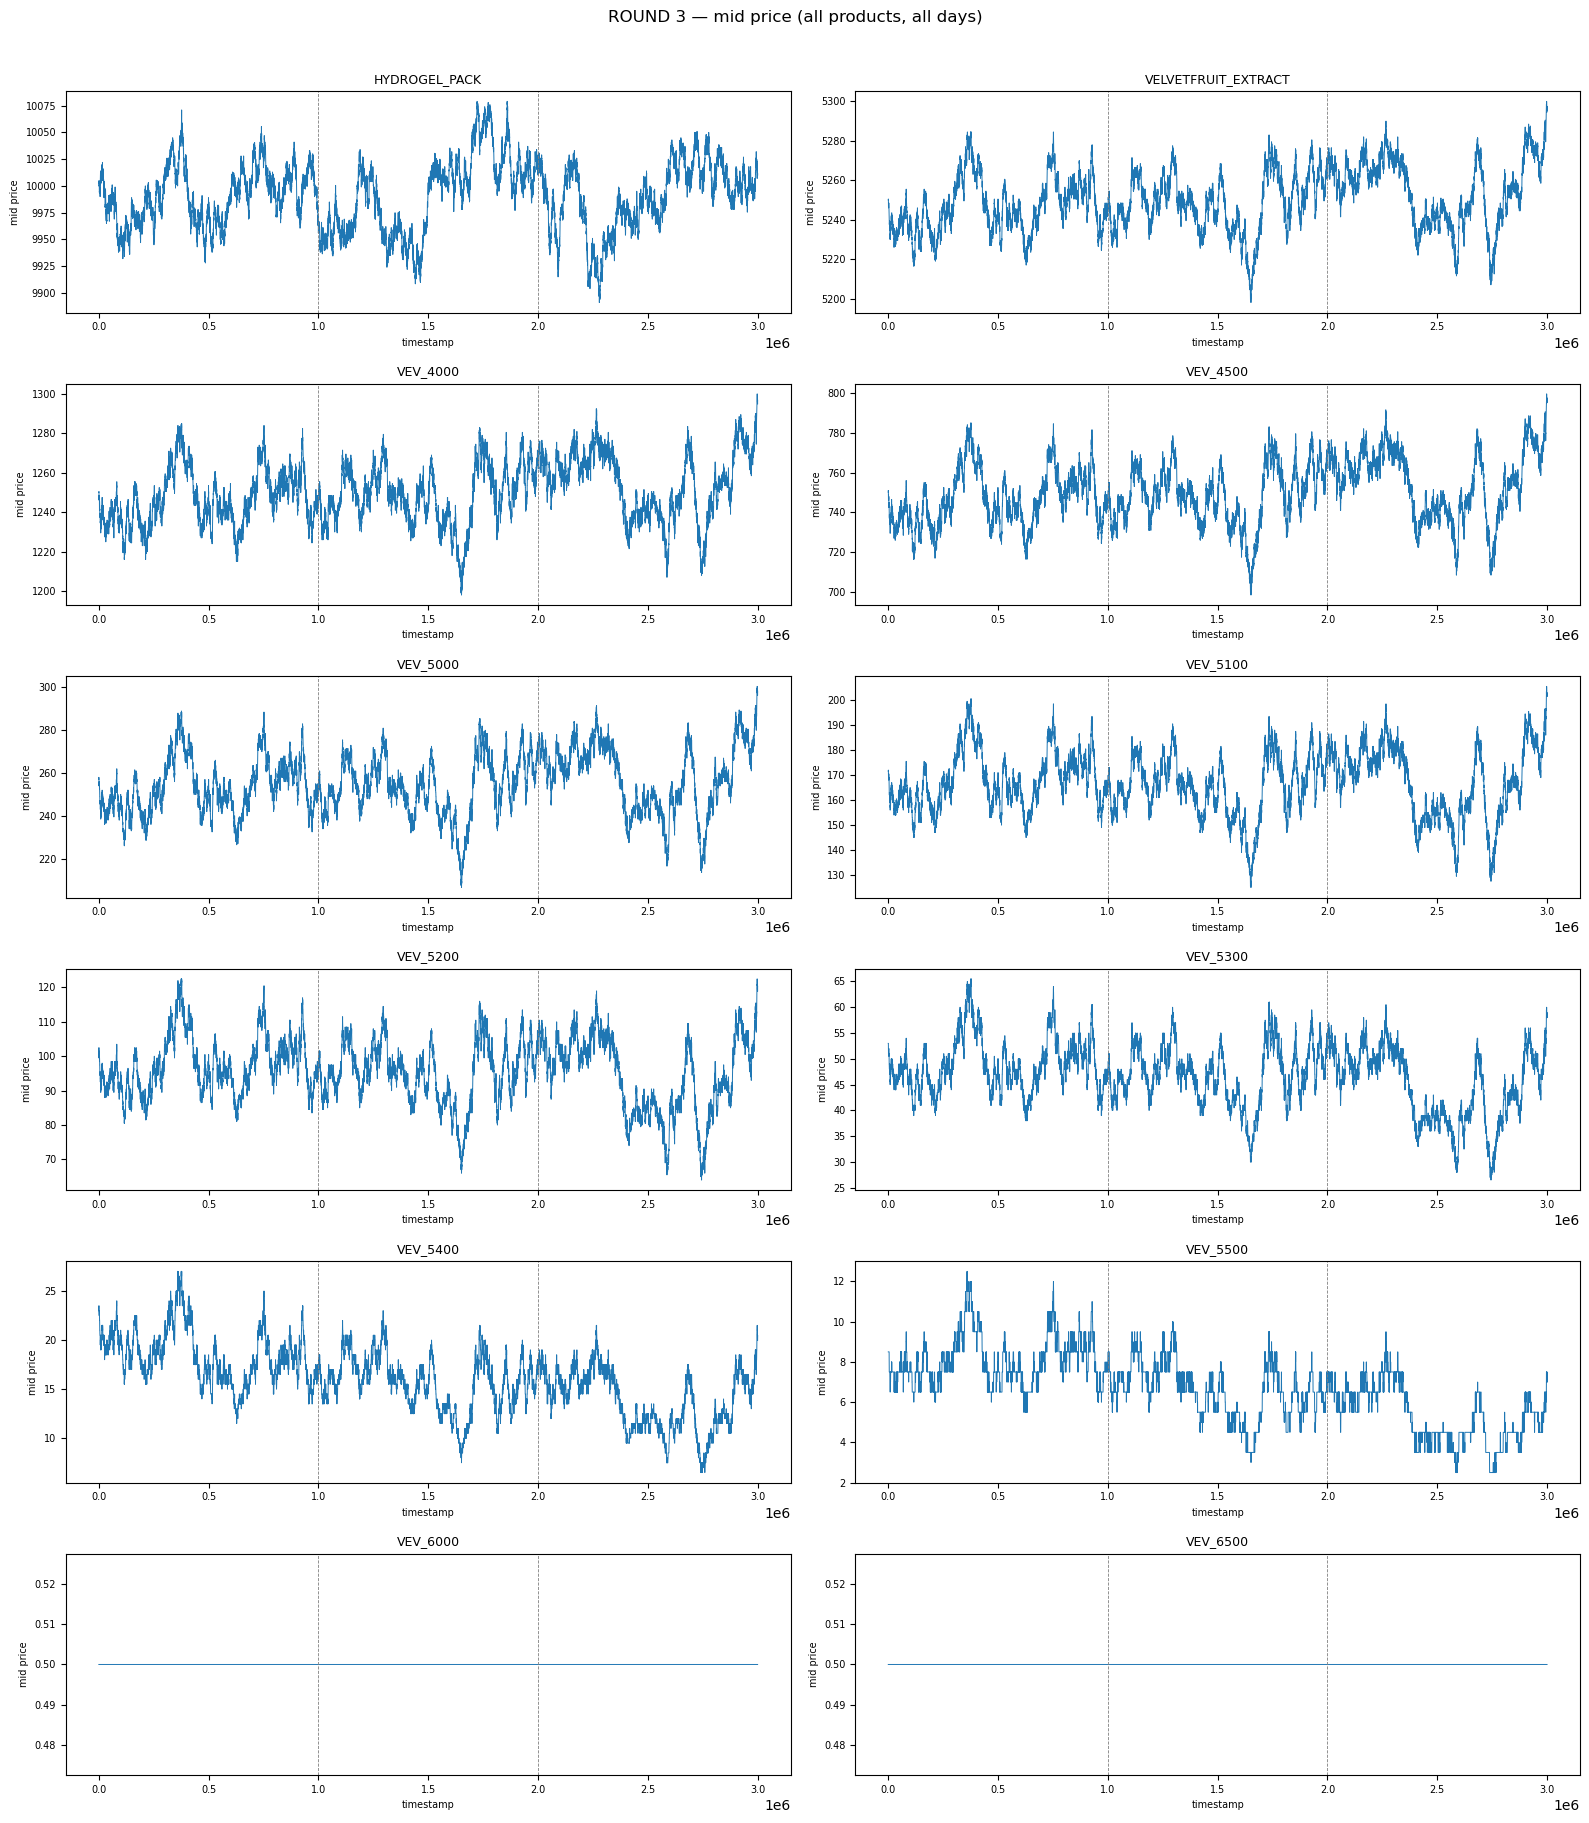

In [5]:
# Mid price — one subplot per product
n = len(products)
ncols = 2
nrows = (n + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, prod in enumerate(products):
    ax = axes[i]
    sub = prices[prices['product'] == prod].sort_values('abs_ts')
    ax.plot(sub['abs_ts'], sub['mid_price'], lw=0.7)
    for sep in [1_000_000, 2_000_000]:
        ax.axvline(sep, color='gray', lw=0.6, ls='--')
    ax.set_title(prod, fontsize=9)
    ax.set_xlabel('timestamp', fontsize=7)
    ax.set_ylabel('mid price', fontsize=7)
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('ROUND 3 — mid price (all products, all days)', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
prices['product']['VEV']

0                    VEV_5400
1                    VEV_6500
2                    VEV_5500
3                    VEV_5200
4                    VEV_5300
                 ...         
359995    VELVETFRUIT_EXTRACT
359996               VEV_4500
359997               VEV_5400
359998               VEV_6500
359999               VEV_5500
Name: product, Length: 360000, dtype: object

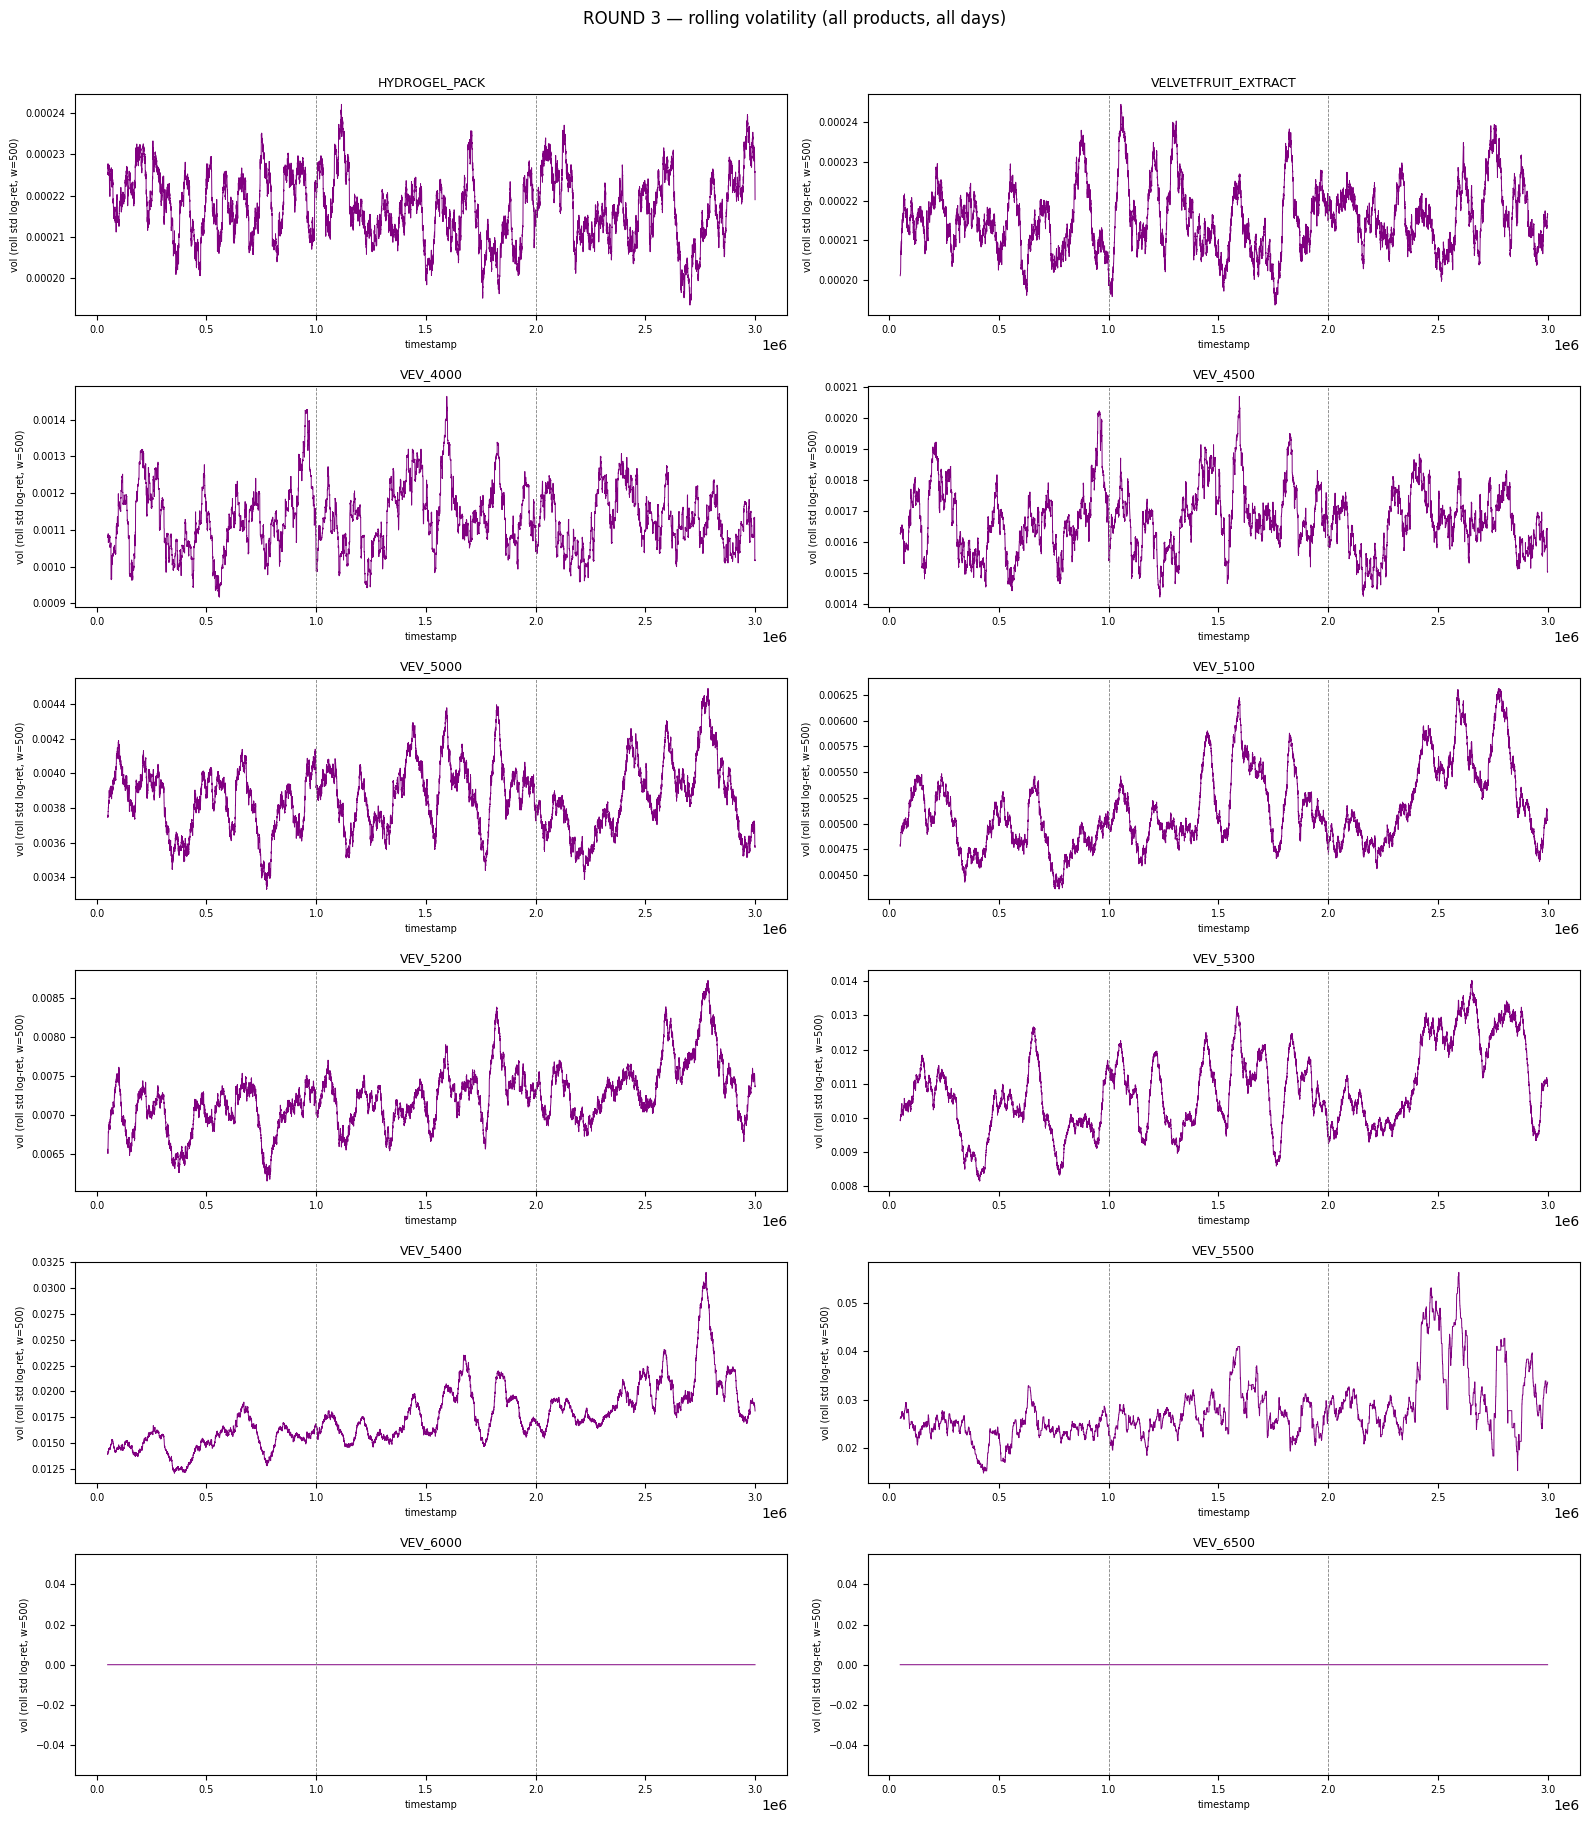

In [ ]:
# Rolling volatility — std of log returns, window=VOL_WINDOW ticks
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, prod in enumerate(products):
    ax = axes[i]
    sub = prices[prices['product'] == prod].sort_values('abs_ts')
    ts = sub['abs_ts'].values
    mid = sub['mid_price'].values

    log_ret = np.diff(np.log(mid))
    roll_vol = pd.Series(log_ret).rolling(VOL_WINDOW, min_periods=VOL_WINDOW).std().values

    ax.plot(ts[1:], roll_vol, lw=0.7, color='purple')
    for sep in [1_000_000, 2_000_000]:
        ax.axvline(sep, color='gray', lw=0.6, ls='--')
    ax.set_title(prod, fontsize=9)
    ax.set_xlabel('timestamp', fontsize=7)
    ax.set_ylabel(f'vol (roll std log-ret, w={VOL_WINDOW})', fontsize=7)
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('ROUND 3 — rolling volatility (all products, all days)', y=1.01)
plt.tight_layout()
plt.show()

In [9]:
# Vol summary table
rows = []
for prod in products:
    sub = prices[prices['product'] == prod].sort_values('abs_ts')
    log_ret = np.diff(np.log(sub['mid_price'].values))
    rows.append({
        'product': prod,
        'mean_vol': np.std(log_ret),
        'max_abs_ret': np.abs(log_ret).max(),
        'n_ticks': len(sub),
    })

summary = pd.DataFrame(rows).set_index('product').sort_values('mean_vol', ascending=False)
print(summary.to_string())

                     mean_vol  max_abs_ret  n_ticks
product                                            
VEV_5500             0.028554     0.251314    30000
VEV_5400             0.017724     0.111226    30000
VEV_5300             0.010858     0.054067    30000
VEV_5200             0.007224     0.033336    30000
VEV_5100             0.005154     0.023296    30000
VEV_5000             0.003861     0.020619    30000
VEV_4500             0.001671     0.011553    30000
VEV_4000             0.001134     0.008900    30000
HYDROGEL_PACK        0.000217     0.001156    30000
VELVETFRUIT_EXTRACT  0.000215     0.001046    30000
VEV_6000             0.000000     0.000000    30000
VEV_6500             0.000000     0.000000    30000


VEV mid:  mean=5250.098  std=15.630  n=30000
AR(2) MEAN (alpha/(1-b1-b2)) = 5250.95   ->   diff to empirical mean: -0.852


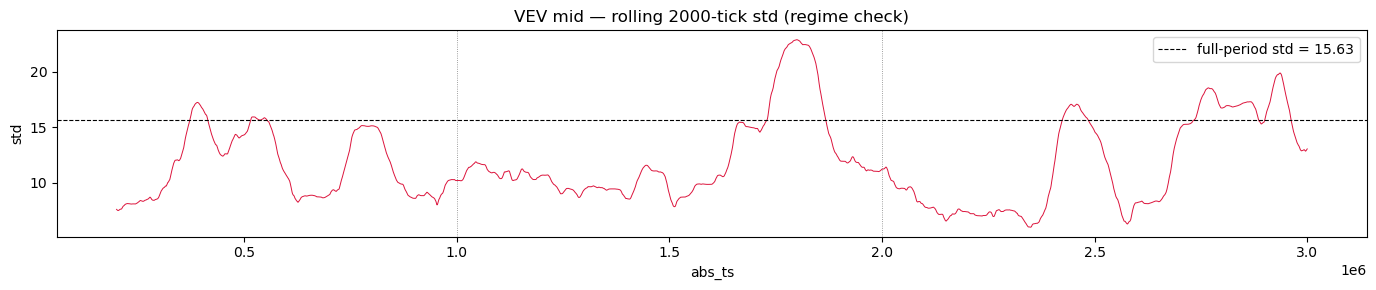

In [10]:
# VEV_STD for engine_ab.py — std dev of VELVETFRUIT_EXTRACT mid over full 3-day period.
# Used in Engine A skew formula: raw_skew = (fair_value - MEAN) / VEV_STD * SKEW_MAX
vev = prices[prices['product'] == 'VELVETFRUIT_EXTRACT'].sort_values('abs_ts')
vev_mid = vev['mid_price']
VEV_MEAN = vev_mid.mean()
VEV_STD  = vev_mid.std()
print(f'VEV mid:  mean={VEV_MEAN:.3f}  std={VEV_STD:.3f}  n={len(vev_mid)}')
print(f'AR(2) MEAN (alpha/(1-b1-b2)) = 5250.95   ->   diff to empirical mean: {VEV_MEAN - 5250.95:+.3f}')

# rolling std diagnostic — flag regime shifts
roll_std = vev_mid.rolling(2000).std()
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(vev['abs_ts'].values, roll_std.values, lw=0.7, color='crimson')
ax.axhline(VEV_STD, color='k', ls='--', lw=0.8, label=f'full-period std = {VEV_STD:.2f}')
for sep in [1_000_000, 2_000_000]:
    ax.axvline(sep, color='grey', ls=':', lw=0.6)
ax.set_title('VEV mid — rolling 2000-tick std (regime check)')
ax.set_xlabel('abs_ts'); ax.set_ylabel('std')
ax.legend()
plt.tight_layout(); plt.show()


In [ ]:
'''
# --- SETTINGS & MODELS ---
MEAN = alpha / (1 - beta1 - beta2)
STRIKES = [4000, 5200, 5300, 5400, 5500, 6000, 6500]
U_LIMIT = 200 # Underlying position limit
O_LIMIT = 300 # Per-option strike limit
REGRET_THRESHOLD = 1500 # Net Delta threshold to trigger "throttling"

# --- MAIN LOOP (EVERY TICK) ---
FUNCTION on_tick(market_state):
    # 1. UPDATE FORECASTS
    S_curr = market_state.underlying.mid
    S_prev = market_state.underlying.prev_mid
    # Predict next tick for short-term scalping bias
    S_next = (beta1 * S_curr) + (beta2 * S_prev) + alpha
    
    # 2. ENGINE A: UNDERLYING MEAN-REVERSION
    # Simple linear scaling: buy more as price drops below mean
    u_target = -1 * (S_curr - MEAN) * SCALE_FACTOR 
    u_order_size = clamp(u_target - current_u_pos, -U_LIMIT, U_LIMIT)
    execute_underlying_trade(u_order_size)

    # 3. ENGINE B: OPTIONS SCALPING (SABR + AR2)
    portfolio_delta = calculate_current_delta(current_u_pos, option_positions)
    
    FOR EACH strike IN STRIKES:
        # Use long-term mean as Forward price since expiry is Round 7
        fair_val = bs_call(MEAN, strike, T_expiry, SABR_IV(strike))
        
        # Calculate 'Lean' based on portfolio risk (Min-Max Regret)
        # If delta is too high, we lower our buy/sell prices to favor selling
        inventory_lean = portfolio_delta / REGRET_THRESHOLD 
        
        # Define quotes: Fair Value +/- Edge, adjusted by lean
        my_bid = fair_val - BASE_EDGE - (inventory_lean * SPREAD)
        my_ask = fair_val + BASE_EDGE - (inventory_lean * SPREAD)

        # 4. THROTTLING (SAFETY OVERLAY)
        # If we are dangerously Long Delta, cancel all Buy orders for calls
        IF portfolio_delta > REGRET_THRESHOLD:
            my_bid = 0 # Stop buying
        IF portfolio_delta < -REGRET_THRESHOLD:
            my_ask = 999999 # Stop selling

        # 5. EXECUTION: Market Making / Scalping
        # We provide liquidity at our calculated lean, capturing the 'ping-pong'
        place_limit_order(strike, my_bid, quantity=O_LIMIT)
        place_limit_order(strike, my_ask, quantity=O_LIMIT)

# --- SUPPORT FUNCTIONS ---
FUNCTION calculate_current_delta(u_pos, opt_positions):
    # Sum of underlying units + (option_qty * option_delta)
    # This represents our total exposure to a 1-unit move in the mean
    RETURN u_pos + SUM(opt.qty * opt.delta FOR opt IN opt_positions)

FUNCTION SABR_IV(strike):
    # Returns the IV from your calibrated SABR model
    # Accounts for the 'smile' across your specific strikes
    RETURN hagan_vol_formula(MEAN, strike, T_expiry, alpha, beta, rho, nu)
'''

## Informed-trader check — big-volume trades (qty 10–30)

Trades CSV has no buyer/seller labels (anonymous). Direction inferred from trade price vs mid at trade tick (price > mid → buyer-initiated, price < mid → seller-initiated). Big-volume trades only exist on `VELVETFRUIT_EXTRACT` — max qty in data is **15**, so the 16-30 bucket is empty.

For each trade, compute forward log-return at horizons {10, 50, 100, 500, 1000} ticks and signed_return = direction × ret. If informed, big trades should have signed_return > 0 (price moves their way).

In [11]:
# Load trades + tag direction + forward signed returns
trade_frames = []
for d in DAYS:
    df = pd.read_csv(f'{BASE}/trades_round_{ROUND_NUM}_day_{d}.csv', sep=';')
    df['abs_ts'] = df['timestamp'] + int(d) * 1_000_000
    trade_frames.append(df)
trades = pd.concat(trade_frames, ignore_index=True)

print(f'trades total: {len(trades)}  |  qty range: {trades.quantity.min()}-{trades.quantity.max()}')
print('big-trade (qty>=10) count by symbol:')
print(trades[trades.quantity >= 10].groupby('symbol').size().sort_values(ascending=False))
print('\nbig-trade qty histogram:')
print(trades[trades.quantity >= 10]['quantity'].value_counts().sort_index().to_string())

# focus VELVETFRUIT_EXTRACT (only symbol with big trades)
SYM = 'VELVETFRUIT_EXTRACT'
vev = prices[prices['product'] == SYM].sort_values('abs_ts').reset_index(drop=True)
vev_ts = vev['abs_ts'].values
vev_mid = vev['mid_price'].values

vt = trades[trades['symbol'] == SYM].sort_values('abs_ts').reset_index(drop=True)
idx = np.searchsorted(vev_ts, vt['abs_ts'].values, side='right') - 1
idx = np.clip(idx, 0, len(vev_ts) - 1)
vt['mid_at'] = vev_mid[idx]
vt['idx_at'] = idx
vt['dir'] = np.where(vt['price'] > vt['mid_at'], 1,
              np.where(vt['price'] < vt['mid_at'], -1, 0))

HORIZ = [10, 50, 100, 500, 1000]
for h in HORIZ:
    fut = np.clip(idx + h, 0, len(vev_ts) - 1)
    vt[f'fwd_ret_{h}'] = np.log(vev_mid[fut] / vt['mid_at'])
    vt[f'signed_{h}']  = vt['dir'] * vt[f'fwd_ret_{h}']

# qty-bin signed-return table (bps, t-stat)
bins = [(3,4),(5,6),(7,9),(10,15)]
rows = []
for lo, hi in bins:
    sub = vt[(vt.quantity>=lo) & (vt.quantity<=hi) & (vt['dir']!=0)]
    r = {'qty_bin': f'{lo}-{hi}', 'n': len(sub),
         'buy_init': int((sub['dir']==1).sum()),
         'sell_init': int((sub['dir']==-1).sum())}
    for h in HORIZ:
        s = sub[f'signed_{h}']
        r[f'mean_bps_h{h}'] = s.mean() * 1e4
        r[f't_h{h}']        = s.mean()/(s.std(ddof=1)/np.sqrt(len(s))) if len(s)>1 and s.std(ddof=1)>0 else np.nan
    rows.append(r)

tbl = pd.DataFrame(rows).set_index('qty_bin')
print('\n=== signed forward returns by qty bin (VEV) — bps & t-stat ===')
print(tbl.to_string(float_format=lambda x: f'{x:+.2f}'))

trades total: 4048  |  qty range: 1-15
big-trade (qty>=10) count by symbol:
symbol
VELVETFRUIT_EXTRACT    78
dtype: int64

big-trade qty histogram:
quantity
10    29
11    10
12    11
13    13
14     9
15     6

=== signed forward returns by qty bin (VEV) — bps & t-stat ===
           n  buy_init  sell_init  mean_bps_h10  t_h10  mean_bps_h50  t_h50  mean_bps_h100  t_h100  mean_bps_h500  t_h500  mean_bps_h1000  t_h1000
qty_bin                                                                                                                                           
3-4      379       196        183         -0.02  -0.07         +0.14  +0.20          -0.10   -0.10          -0.77   -0.45           +1.90    +0.93
5-6      435       258        177         +0.32  +1.10         +0.69  +1.18          +1.99   +2.44          +2.06   +1.22           +2.11    +1.03
7-9      480       251        229         +0.70  +2.70         +0.48  +0.86          +0.80   +1.03          +2.54   +1.68           -0.43

big trades (qty>=10) on VELVETFRUIT_EXTRACT: n=15, buy_init=15, sell_init=0


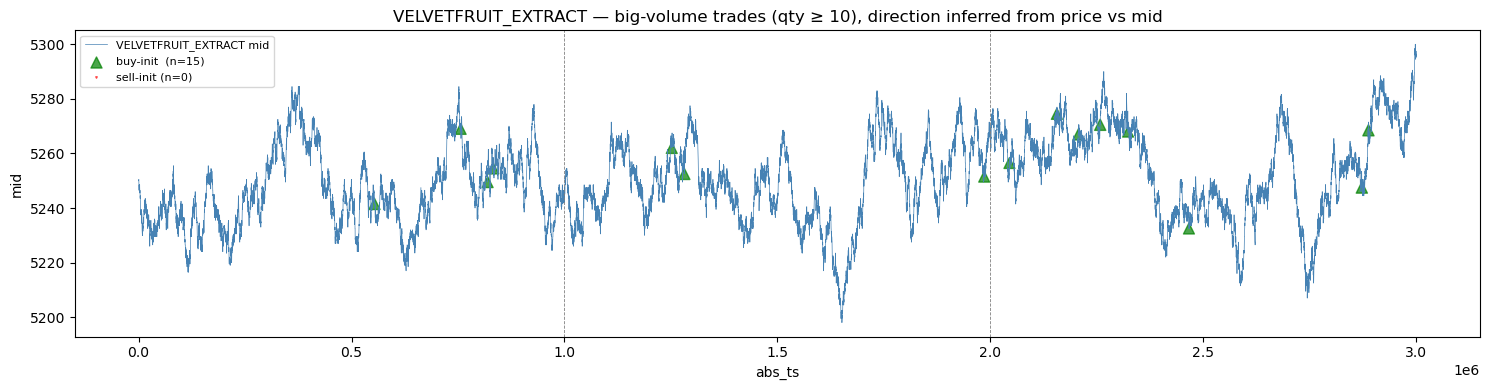

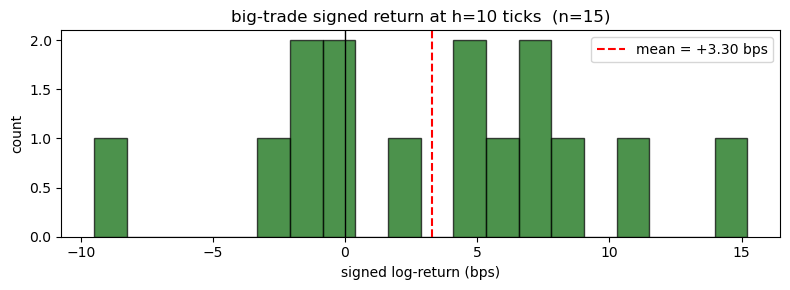


=== Verdict — informed trader on VELVETFRUIT_EXTRACT? ===
* big trades (qty>=10): 15 total, 15 buys / 0 sells
  → extreme one-sidedness suggests single accumulating buyer, not noise.
* mean signed return @ h=10: +3.30 bps  (t=2.04)
* mean signed return @ h=1000: +0.17 bps — drift persists past impact decay
* small trades (qty<=5) signed h=1000: +1.79 bps (baseline)
=> Yes — big-volume trades on VEV carry directional information beyond pure market impact.



In [14]:
# Big-trade arrows over VEV mid (qty>=10)
big = vt[vt.quantity >= 14].copy()
print(f'big trades (qty>=10) on {SYM}: n={len(big)}, '
      f'buy_init={(big.dir==1).sum()}, sell_init={(big.dir==-1).sum()}')

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(vev_ts, vev_mid, lw=0.5, color='steelblue', label=f'{SYM} mid')
buy  = big[big.dir == 1]
sell = big[big.dir == -1]
ax.scatter(buy['abs_ts'],  buy['mid_at'],  marker='^', s=20+buy['quantity']*3,
           color='green', alpha=0.7, label=f'buy-init  (n={len(buy)})')
ax.scatter(sell['abs_ts'], sell['mid_at'], marker='v', s=20+sell['quantity']*3,
           color='red',   alpha=0.7, label=f'sell-init (n={len(sell)})')
for sep in [1_000_000, 2_000_000]:
    ax.axvline(sep, color='gray', lw=0.6, ls='--')
ax.set_title(f'{SYM} — big-volume trades (qty ≥ 10), direction inferred from price vs mid')
ax.set_xlabel('abs_ts'); ax.set_ylabel('mid')
ax.legend(loc='best', fontsize=8)
plt.tight_layout(); plt.show()

# distribution of signed returns at h=10 (most significant horizon)
fig, ax = plt.subplots(figsize=(8, 3))
s10 = big[big.dir != 0]['signed_10'].values * 1e4
ax.hist(s10, bins=20, color='darkgreen', alpha=0.7, edgecolor='k')
ax.axvline(0, color='k', lw=1)
ax.axvline(s10.mean(), color='red', lw=1.5, ls='--',
           label=f'mean = {s10.mean():+.2f} bps')
ax.set_title(f'big-trade signed return at h=10 ticks  (n={len(s10)})')
ax.set_xlabel('signed log-return (bps)'); ax.set_ylabel('count')
ax.legend()
plt.tight_layout(); plt.show()

# Conclusion print
print(f"""
=== Verdict — informed trader on {SYM}? ===
* big trades (qty>=10): {len(big)} total, {(big.dir==1).sum()} buys / {(big.dir==-1).sum()} sells
  → extreme one-sidedness suggests single accumulating buyer, not noise.
* mean signed return @ h=10: {s10.mean():+.2f} bps  (t={s10.mean()/(s10.std(ddof=1)/np.sqrt(len(s10))):.2f})
* mean signed return @ h=1000: {big[big.dir!=0]['signed_1000'].mean()*1e4:+.2f} bps — drift persists past impact decay
* small trades (qty<=5) signed h=1000: {vt[(vt.quantity<=5)&(vt.dir!=0)]['signed_1000'].mean()*1e4:+.2f} bps (baseline)
=> Yes — big-volume trades on VEV carry directional information beyond pure market impact.
""")

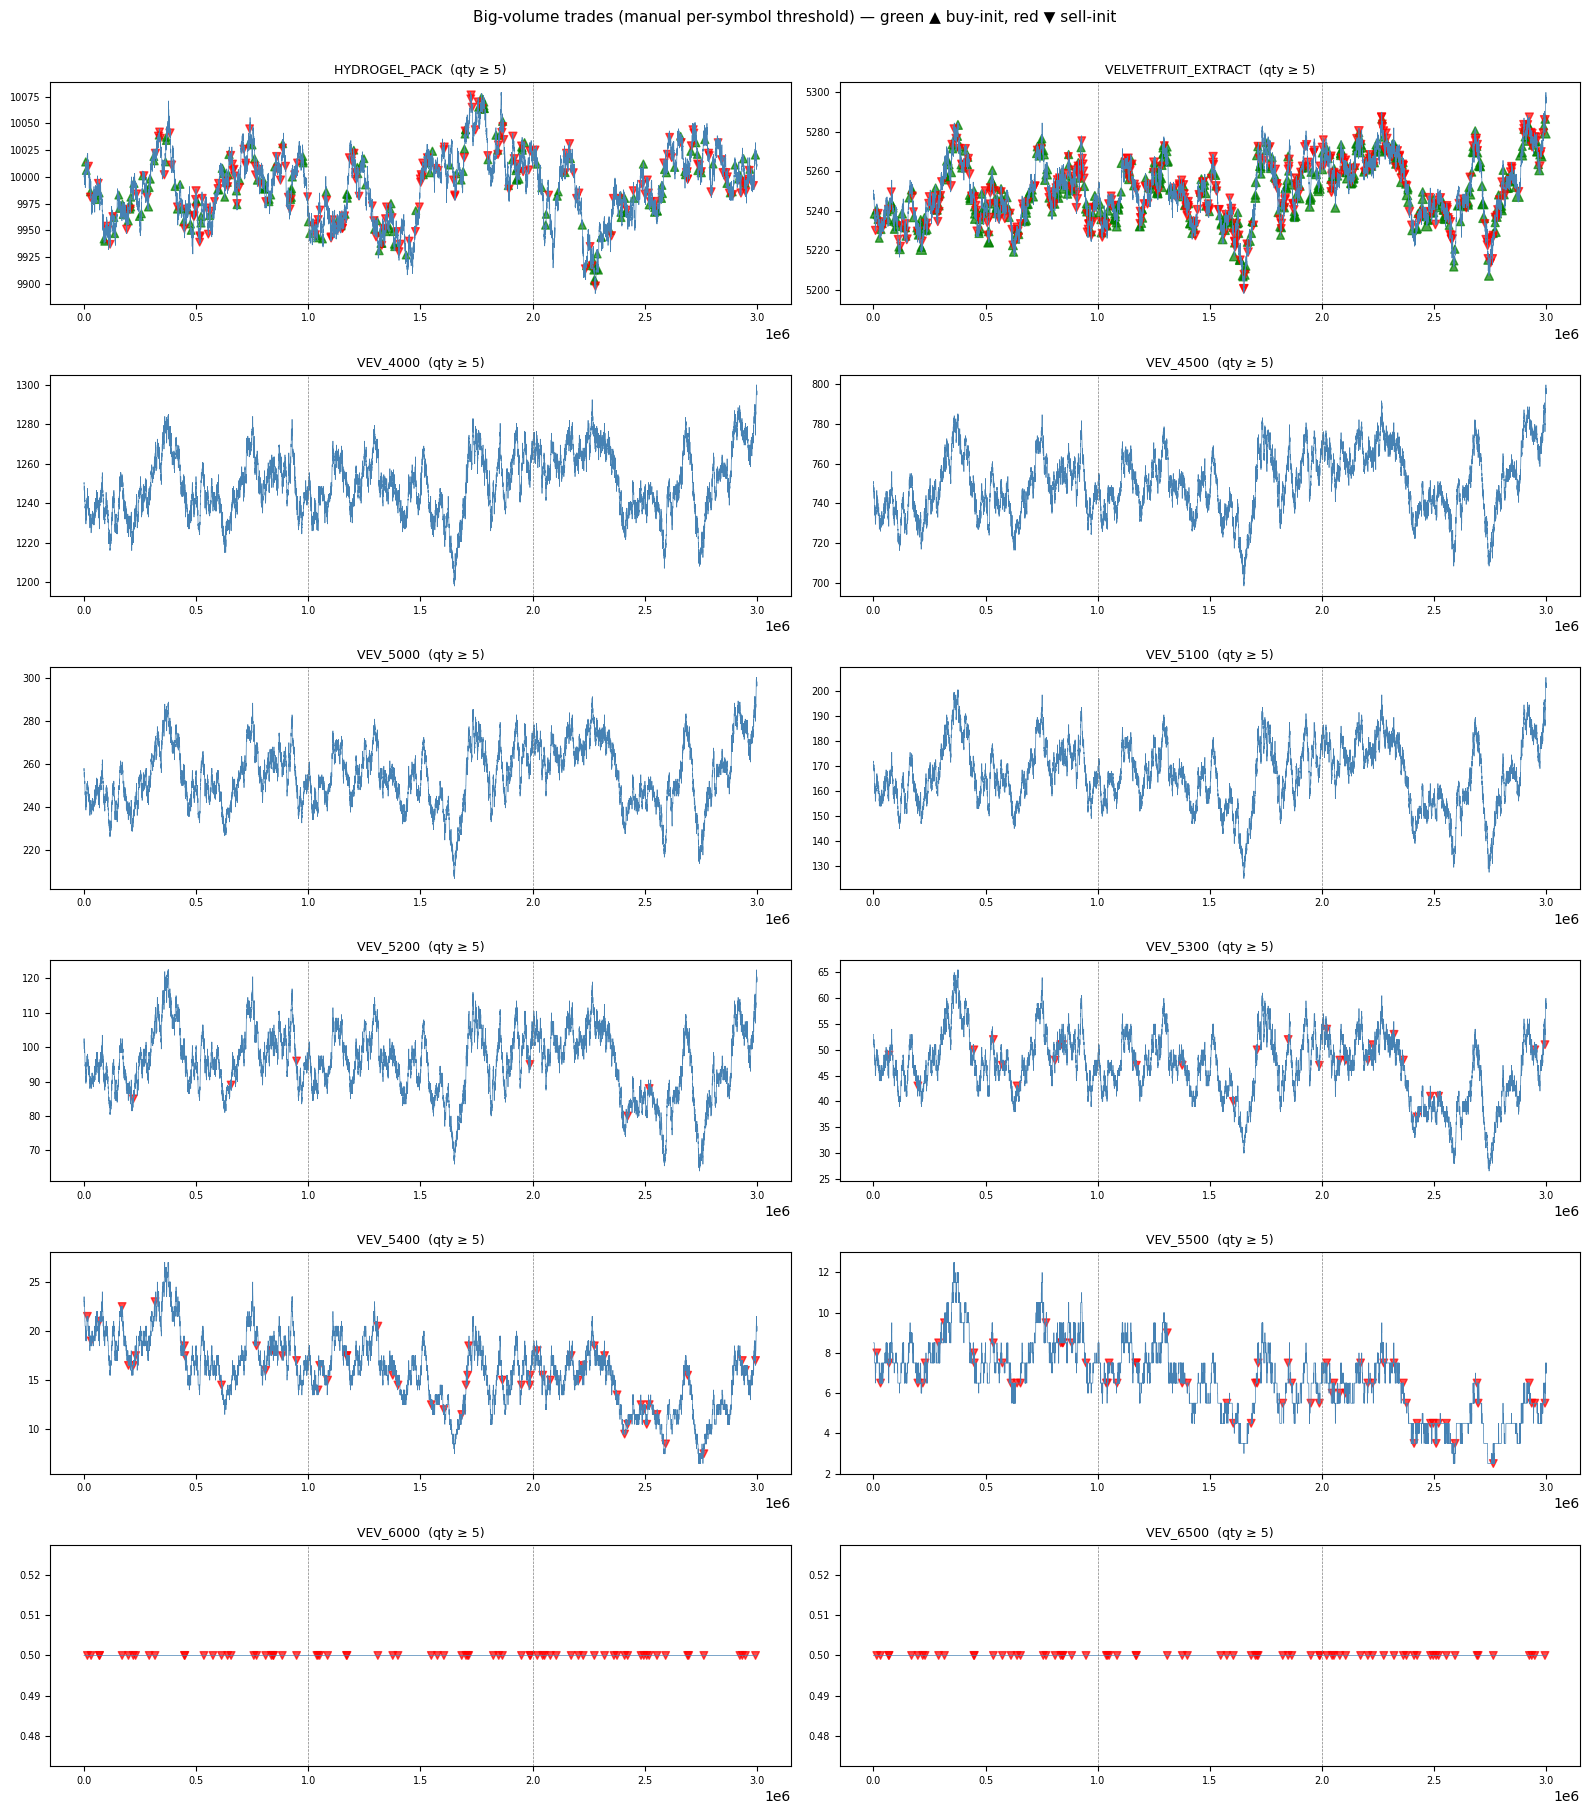


=== per-symbol big-trade summary (h=100 ticks) ===
                     thresh  n_trades  n_big  big_buy  big_sell  mean_signed_h100_bps  t_h100
symbol                                                                                       
HYDROGEL_PACK             5      1010    417      216       201                 +1.40   +1.56
VELVETFRUIT_EXTRACT       5      1372    993      585       408                 +1.50   +2.78
VEV_4000                  5       464      0        0         0                   NaN     NaN
VEV_4500                  5         1      0        0         0                   NaN     NaN
VEV_5000                  5         1      0        0         0                   NaN     NaN
VEV_5100                  5         1      0        0         0                   NaN     NaN
VEV_5200                  5        18      6        0         6               -259.37   -0.85
VEV_5300                  5       121     28        0        27                +13.84   +0.11
VEV_5400

In [17]:
# Big-trade arrows for ALL products. Manual per-symbol qty threshold (qty >= THRESH).
# Edit BIG_QTY below to tune. Symbols missing from dict fall back to DEFAULT_THRESH.
val = 5
BIG_QTY = {
    'VELVETFRUIT_EXTRACT': val,
    'HYDROGEL_PACK':       val,
    'VEV_4000':            val,
    'VEV_4500':            val,
    'VEV_5000':            val,
    'VEV_5100':            val,
    'VEV_5200':            val,
    'VEV_5300':            val,
    'VEV_5400':            val,
    'VEV_5500':            val,
    'VEV_6000':            val,
    'VEV_6500':            val,
}
DEFAULT_THRESH = 5

all_syms = sorted(prices['product'].unique())
ncols = 2
nrows = (len(all_syms) + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

verdict_rows = []
for i, sym in enumerate(all_syms):
    ax = axes[i]
    psub = prices[prices['product'] == sym].sort_values('abs_ts').reset_index(drop=True)
    p_ts  = psub['abs_ts'].values
    p_mid = psub['mid_price'].values

    tsub = trades[trades['symbol'] == sym].sort_values('abs_ts').reset_index(drop=True)
    ax.plot(p_ts, p_mid, lw=0.5, color='steelblue')

    thresh = BIG_QTY.get(sym, DEFAULT_THRESH)

    if len(tsub) > 0:
        idx = np.clip(np.searchsorted(p_ts, tsub['abs_ts'].values, side='right') - 1, 0, len(p_ts)-1)
        tsub = tsub.assign(mid_at=p_mid[idx])
        tsub['dir'] = np.where(tsub['price'] > tsub['mid_at'], 1,
                       np.where(tsub['price'] < tsub['mid_at'], -1, 0))

        big  = tsub[tsub['quantity'] >= thresh]
        buy  = big[big['dir'] ==  1]
        sell = big[big['dir'] == -1]
        ax.scatter(buy['abs_ts'],  buy['mid_at'],  marker='^',
                   s=15 + buy['quantity']*3,  color='green', alpha=0.7)
        ax.scatter(sell['abs_ts'], sell['mid_at'], marker='v',
                   s=15 + sell['quantity']*3, color='red',   alpha=0.7)

        fut = np.clip(idx + 100, 0, len(p_ts) - 1)
        sret = (tsub['dir'] * np.log(p_mid[fut] / tsub['mid_at']))
        big_sret = sret[tsub['quantity'] >= thresh]
        big_sret = big_sret[big_sret.notna() & (tsub.loc[big_sret.index, 'dir'] != 0)]
        verdict_rows.append({
            'symbol': sym,
            'thresh': thresh,
            'n_trades': len(tsub),
            'n_big': len(big),
            'big_buy':  int((big['dir']== 1).sum()),
            'big_sell': int((big['dir']==-1).sum()),
            'mean_signed_h100_bps': big_sret.mean()*1e4 if len(big_sret) else np.nan,
            't_h100': (big_sret.mean()/(big_sret.std(ddof=1)/np.sqrt(len(big_sret))))
                      if len(big_sret) > 1 and big_sret.std(ddof=1) > 0 else np.nan,
        })

    for sep in [1_000_000, 2_000_000]:
        ax.axvline(sep, color='gray', lw=0.5, ls='--')
    ax.set_title(f'{sym}  (qty ≥ {thresh})', fontsize=9)
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Big-volume trades (manual per-symbol threshold) — green ▲ buy-init, red ▼ sell-init',
             y=1.005, fontsize=11)
plt.tight_layout(); plt.show()

verdict = pd.DataFrame(verdict_rows).set_index('symbol')
print('\n=== per-symbol big-trade summary (h=100 ticks) ===')
print(verdict.to_string(float_format=lambda x: f'{x:+.2f}'))